# Model Evaluation and Comparison

Combines results from `06_baseline_models.ipynb`, `07_statistical_models.ipynb`, `08_ml_models.ipynb`, and `09_deep_learning.ipynb` (proposal.txt Sections 16-19) into a single accuracy/computation comparison, an overlay forecast plot, Diebold-Mariano significance tests, and a peak-demand comparison. Run those four notebooks first so their `reports/*_metrics.csv` and `reports/*_predictions.csv` files exist.

In [ ]:
import os
import sys
from pathlib import Path

import yaml

# This notebook only reads from /kaggle/working (reports/*.csv produced by
# notebooks 6-9 earlier in the same Kaggle session), never from
# /kaggle/input, so IS_KAGGLE just needs KAGGLE_KERNEL_RUN_TYPE (always set
# on Kaggle, unlike /kaggle/input which only exists once a dataset is
# attached) -- no dataset needs to be attached for this notebook specifically.
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    REPO_ROOT = Path("/kaggle/working")
    config = {
        "data": {"target_col": "demand"},
        "peak_demand": {"percentile_threshold": 0.95, "seasonal": True},
    }
else:
    def find_repo_root(start: Path) -> Path:
        for parent in [start, *start.parents]:
            if (parent / "config.yaml").exists():
                return parent
        raise FileNotFoundError("config.yaml not found in any parent directory")

    REPO_ROOT = find_repo_root(Path.cwd())
    sys.path.insert(0, str(REPO_ROOT))

    with open(REPO_ROOT / "config.yaml") as f:
        config = yaml.safe_load(f)

config

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# On Kaggle, src/ isn't on disk (only pasted cells are) -- this is an
# identical inline copy of src/evaluation/metrics.py::diebold_mariano_test.
# Keep it in sync with src/ if that logic ever changes.
if IS_KAGGLE:
    from scipy import stats

    def diebold_mariano_test(errors_a, errors_b, power=2):
        d = np.abs(errors_a) ** power - np.abs(errors_b) ** power
        d_mean = d.mean()
        d_var = d.var(ddof=1) / len(d)
        dm_stat = d_mean / np.sqrt(d_var)
        p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
        return dm_stat, p_value
else:
    from src.evaluation.metrics import diebold_mariano_test

REPORTS_DIR = REPO_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TARGET_COL = config["data"]["target_col"]

## Load metrics from all model notebooks

In [3]:
METRICS_FILES = {
    "Baseline": "baseline_metrics.csv",
    "Statistical": "statistical_metrics.csv",
    "Machine Learning": "ml_metrics.csv",
    "Deep Learning": "dl_metrics.csv",
}

metrics_frames = []
for family, filename in METRICS_FILES.items():
    path = REPORTS_DIR / filename
    if not path.exists():
        print(f"Skipping {family}: {path} not found -- run the corresponding notebook first")
        continue
    frame = pd.read_csv(path)
    frame.insert(0, "family", family)
    metrics_frames.append(frame)

all_metrics = pd.concat(metrics_frames, ignore_index=True)
all_metrics = all_metrics.sort_values("rmse").reset_index(drop=True)
all_metrics

,family,model,mae,rmse,mape,smape,mase,training_time_seconds,prediction_time_seconds
0,Machine Learning,Random Forest,0.033559,1.043491,0.002605,0.002562,0.000296,10.580783,0.063712
1,Machine Learning,XGBoost,1.111359,2.688061,0.075628,0.075572,0.009800,2.701997,0.010554
2,Statistical,"ARIMA(2,1,2)",79.858537,100.367779,5.377366,5.337663,NaN,NaN,NaN
3,Statistical,"SARIMA(1,1,1)(1,1,1,24)",80.024426,100.591412,5.377545,5.348739,NaN,NaN,NaN
4,Deep Learning,LSTM,80.297592,100.916799,5.391555,5.367068,0.708114,17.679853,1.067433
5,Baseline,Moving average (24h),81.332470,102.459940,5.473647,5.435826,0.717041,NaN,NaN
6,Baseline,Seasonal naive (previous week),113.315391,141.643410,7.608635,7.574782,0.999008,NaN,NaN
7,Baseline,Seasonal naive (previous day),112.941008,142.237362,7.588907,7.550213,0.995708,NaN,NaN
8,Baseline,Naive (previous hour),114.125999,143.161920,7.659646,7.623723,1.006155,NaN,NaN


## Accuracy comparison

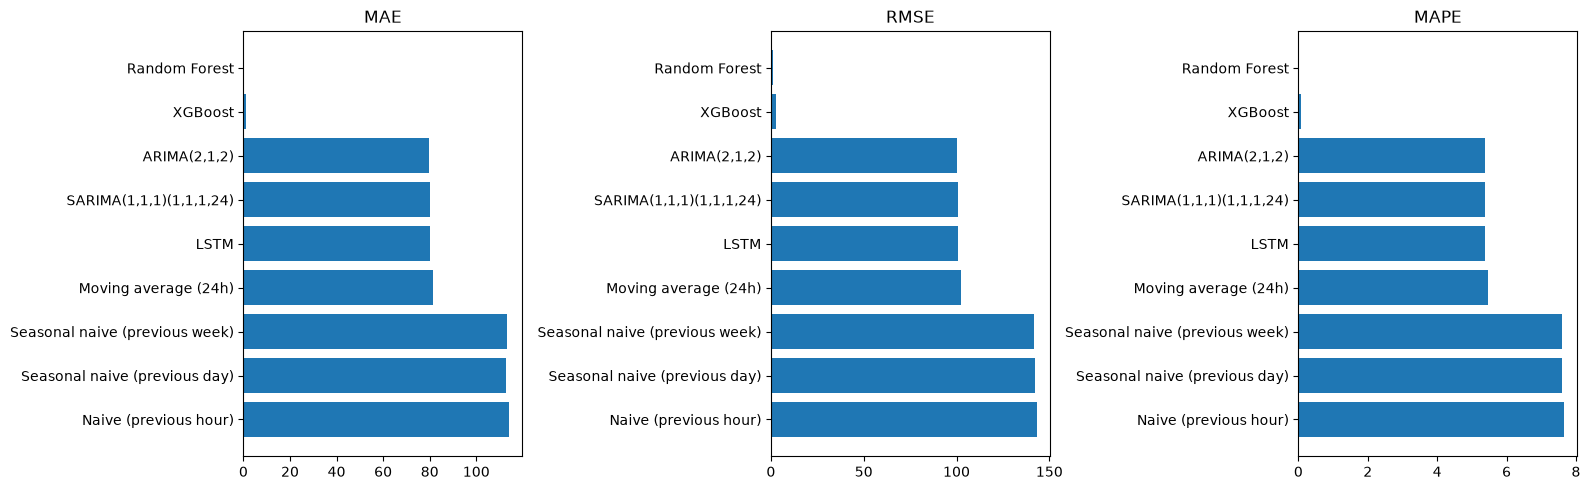

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["mae", "rmse", "mape"]):
    ax.barh(all_metrics["model"], all_metrics[metric])
    ax.set_title(metric.upper())
    ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "comparison_accuracy.png", dpi=150, bbox_inches="tight")

## Computational cost comparison

Only available for models trained in `08_ml_models.ipynb` and `09_deep_learning.ipynb` -- the baseline and statistical notebooks don't currently persist timing figures, so those rows are dropped here.

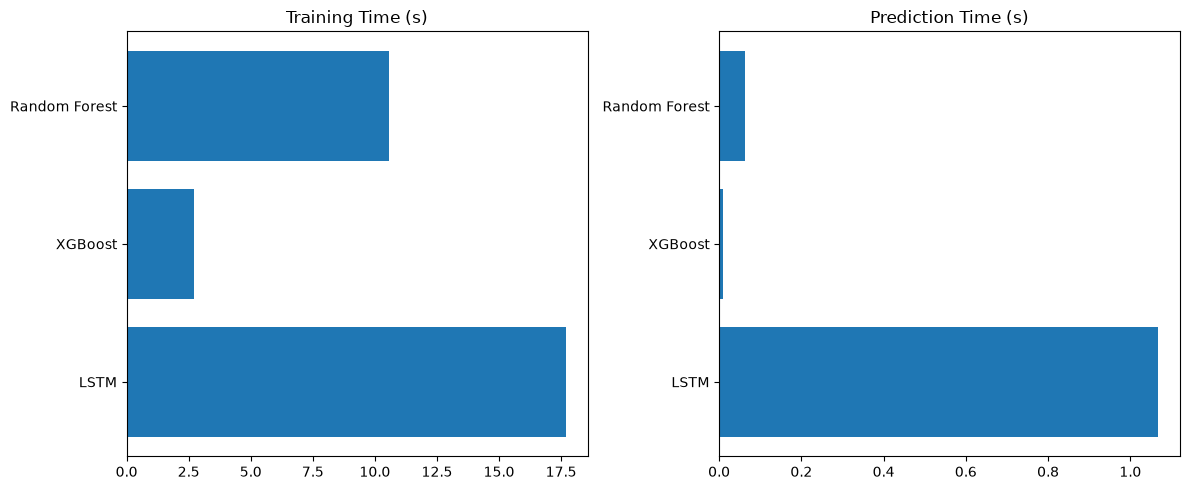

In [5]:
timed = all_metrics.dropna(subset=["training_time_seconds"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(timed["model"], timed["training_time_seconds"])
axes[0].set_title("Training Time (s)")
axes[0].invert_yaxis()
axes[1].barh(timed["model"], timed["prediction_time_seconds"])
axes[1].set_title("Prediction Time (s)")
axes[1].invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "comparison_computation.png", dpi=150, bbox_inches="tight")

## Load predictions from all model notebooks

In [6]:
PREDICTIONS_FILES = ["baseline_predictions.csv", "statistical_predictions.csv", "ml_predictions.csv", "dl_predictions.csv"]

prediction_frames = []
for filename in PREDICTIONS_FILES:
    path = REPORTS_DIR / filename
    if not path.exists():
        print(f"Skipping {filename}: not found -- run the corresponding notebook first")
        continue
    frame = pd.read_csv(path, parse_dates=["timestamp"])
    prediction_frames.append(frame)

all_predictions = pd.concat(prediction_frames, ignore_index=True)
print(f"Models with saved predictions: {sorted(all_predictions['model'].unique())}")

Models with saved predictions: ['ARIMA(2,1,2)', 'LSTM', 'Moving average (24h)', 'Naive (previous hour)', 'Random Forest', 'SARIMA(1,1,1)(1,1,1,24)', 'Seasonal naive (previous day)', 'Seasonal naive (previous week)', 'XGBoost']


## Overlay forecast comparison

Each model's test window can differ slightly (baseline/statistical notebooks predict from `demand_clean.csv`; ML/DL notebooks predict from the lag/rolling-engineered `features.csv`, which drops a short warm-up period), so this plots the most recent 14 days common to every model's test period, rather than forcing a mismatched shared window.

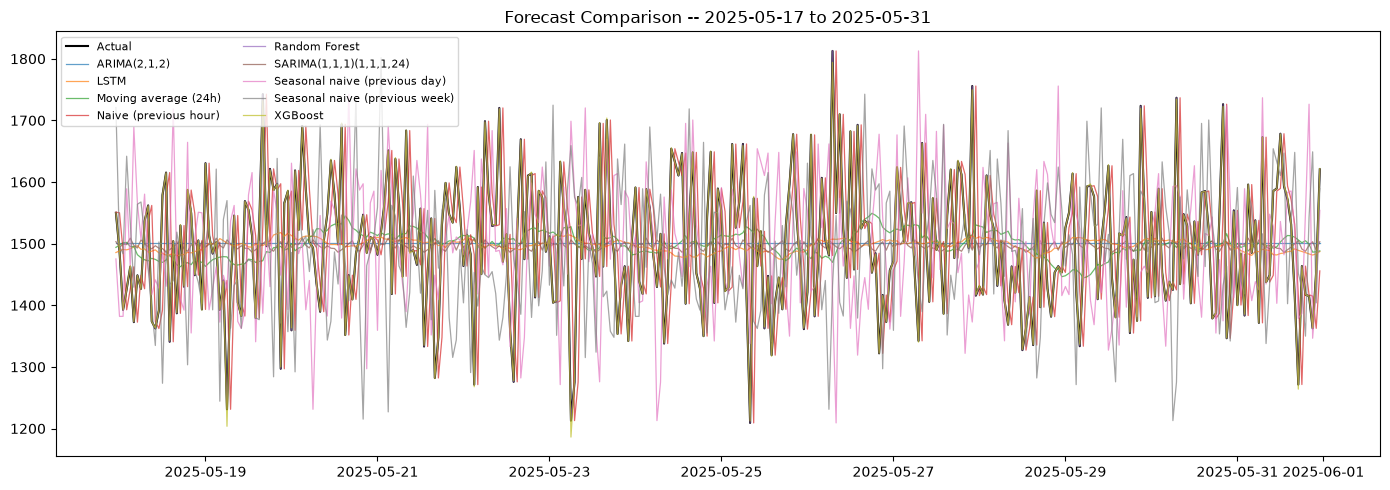

In [7]:
common_start = all_predictions.groupby("model")["timestamp"].min().max()
common_end = all_predictions.groupby("model")["timestamp"].max().min()
window_start = max(common_start, common_end - pd.Timedelta(days=14))

window = all_predictions[(all_predictions["timestamp"] >= window_start) & (all_predictions["timestamp"] <= common_end)]

fig, ax = plt.subplots(figsize=(14, 5))
actual_plotted = False
for model_name, group in window.groupby("model"):
    group = group.sort_values("timestamp")
    if not actual_plotted:
        ax.plot(group["timestamp"], group["actual"], label="Actual", color="black", linewidth=1.5)
        actual_plotted = True
    ax.plot(group["timestamp"], group["predicted"], label=model_name, alpha=0.7, linewidth=0.9)

ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.set_title(f"Forecast Comparison -- {window_start.date()} to {common_end.date()}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "comparison_forecast_overlay.png", dpi=150, bbox_inches="tight")

## Diebold-Mariano significance tests

Compares forecast-error series pairwise using `src/evaluation/metrics.py::diebold_mariano_test`, aligned on each pair's overlapping timestamps. A p-value below 0.05 indicates the two models' accuracy differs by more than random variation (proposal.txt Section 16).

In [8]:
error_by_model = {}
for model_name, group in all_predictions.groupby("model"):
    group = group.drop_duplicates("timestamp").set_index("timestamp").sort_index()
    error_by_model[model_name] = group["actual"] - group["predicted"]

model_names = sorted(error_by_model.keys())
dm_results = []
for i, model_a in enumerate(model_names):
    for model_b in model_names[i + 1:]:
        common_idx = error_by_model[model_a].index.intersection(error_by_model[model_b].index)
        if len(common_idx) < 30:
            continue
        dm_stat, p_value = diebold_mariano_test(
            error_by_model[model_a].loc[common_idx].to_numpy(),
            error_by_model[model_b].loc[common_idx].to_numpy(),
        )
        dm_results.append({
            "model_a": model_a,
            "model_b": model_b,
            "n_common_obs": len(common_idx),
            "dm_statistic": dm_stat,
            "p_value": p_value,
            "significant_at_0.05": p_value < 0.05,
        })

dm_df = pd.DataFrame(dm_results).sort_values("p_value").reset_index(drop=True)
dm_df

,model_a,model_b,n_common_obs,dm_statistic,p_value,significant_at_0.05
0,"ARIMA(2,1,2)",Moving average (24h),7121,-8.770176,0.000000e+00,True
1,"ARIMA(2,1,2)",Naive (previous hour),7121,-34.604755,0.000000e+00,True
2,"ARIMA(2,1,2)",Random Forest,7096,58.714731,0.000000e+00,True
3,"ARIMA(2,1,2)",Seasonal naive (previous day),7121,-33.630840,0.000000e+00,True
4,"ARIMA(2,1,2)",XGBoost,7096,58.797117,0.000000e+00,True
5,"ARIMA(2,1,2)",Seasonal naive (previous week),7121,-34.636569,0.000000e+00,True
6,LSTM,Random Forest,7096,58.725588,0.000000e+00,True
7,LSTM,Naive (previous hour),7096,-34.342117,0.000000e+00,True
8,LSTM,XGBoost,7096,58.805729,0.000000e+00,True
9,Moving average (24h),Naive (previous hour),7121,-33.525207,0.000000e+00,True


## Peak-demand accuracy comparison

Restricts evaluation to each model's own hours where actual demand was at or above the `config.yaml` peak-demand threshold (proposal.txt Section 21).

In [9]:
peak_threshold_pct = config["peak_demand"]["percentile_threshold"]

peak_results = []
for model_name, group in all_predictions.groupby("model"):
    group = group.drop_duplicates("timestamp")
    threshold = group["actual"].quantile(peak_threshold_pct)
    peak_rows = group[group["actual"] >= threshold]
    if peak_rows.empty:
        continue
    peak_results.append({
        "model": model_name,
        "peak_threshold": threshold,
        "n_peak_hours": len(peak_rows),
        "peak_mae": np.mean(np.abs(peak_rows["actual"] - peak_rows["predicted"])),
    })

peak_df = pd.DataFrame(peak_results).sort_values("peak_mae").reset_index(drop=True)
peak_df

,model,peak_threshold,n_peak_hours,peak_mae
0,Random Forest,1666.225297,355,0.129355
1,XGBoost,1666.225297,355,3.314865
2,Seasonal naive (previous day),1665.881098,357,205.843931
3,"ARIMA(2,1,2)",1665.881098,357,206.628711
4,Seasonal naive (previous week),1665.881098,357,206.885088
5,Moving average (24h),1665.881098,357,207.912209
6,"SARIMA(1,1,1)(1,1,1,24)",1665.881098,357,210.083926
7,LSTM,1666.225297,355,211.242436
8,Naive (previous hour),1665.881098,357,219.890900


## Save the combined comparison tables

In [10]:
COMPARISON_PATH = REPORTS_DIR / "model_comparison.csv"
all_metrics.to_csv(COMPARISON_PATH, index=False)

DM_PATH = REPORTS_DIR / "dm_test_results.csv"
dm_df.to_csv(DM_PATH, index=False)

PEAK_PATH = REPORTS_DIR / "peak_demand_comparison.csv"
peak_df.to_csv(PEAK_PATH, index=False)

print(f"Saved combined comparison table to {COMPARISON_PATH}")
print(f"Saved Diebold-Mariano test results to {DM_PATH}")
print(f"Saved peak-demand comparison to {PEAK_PATH}")

Saved combined comparison table to C:\dev\Electricity-Demand-Forecasting-Using-Statistical-Machine-Learning-and-Deep-Learning-Methods\reports\model_comparison.csv
Saved Diebold-Mariano test results to C:\dev\Electricity-Demand-Forecasting-Using-Statistical-Machine-Learning-and-Deep-Learning-Methods\reports\dm_test_results.csv
Saved peak-demand comparison to C:\dev\Electricity-Demand-Forecasting-Using-Statistical-Machine-Learning-and-Deep-Learning-Methods\reports\peak_demand_comparison.csv


## Export data for the dashboard

Writes the JSON files `dashboard/src/loadData.ts` looks for under `dashboard/public/data/` (falling back to mock data if they're missing -- see that file). Locally these land directly in the repo so `npm run dev` picks them up immediately; on Kaggle there's no dashboard checkout to write into, so they're staged under `/kaggle/working/dashboard_data/` instead for you to download and copy into `dashboard/public/data/` yourself.

The dashboard's `ModelName` type only has slots for four models (`SeasonalNaive`, `SARIMA`, `XGBoost`, `LSTM`), so `METRIC_NAME_MAP` below picks one real model per slot rather than showing all nine. The demand chart uses SARIMA's predictions specifically, not XGBoost's -- XGBoost (and Random Forest) currently show implausibly small errors (~1-3 kW vs ~80-200 kW for every other model, see the peak-demand notebook's note), almost certainly from a feature that leaks the current-hour target during feature engineering. That needs fixing before XGBoost's own numbers should be trusted for anything, including this chart.

In [ ]:
import json

import joblib

# On Kaggle, src/ isn't on disk -- identical inline copy of
# src/evaluation/export_dashboard_data.py. Keep in sync if that logic changes.
if IS_KAGGLE:
    def export_demand_series(df, output_dir, filename="demand.json"):
        records = df[["timestamp", "actual", "predicted"]].to_dict(orient="records")
        _write_json(records, output_dir, filename)

    def export_metrics(df, output_dir, filename="metrics.json"):
        records = df[["model", "mae", "rmse", "mape", "trainingTimeSeconds"]].to_dict(orient="records")
        _write_json(records, output_dir, filename)

    def export_feature_importance(df, output_dir, filename="feature_importance.json"):
        records = df[["feature", "importance"]].to_dict(orient="records")
        _write_json(records, output_dir, filename)

    def _write_json(records, output_dir, filename):
        import os
        os.makedirs(output_dir, exist_ok=True)
        with open(os.path.join(output_dir, filename), "w") as f:
            json.dump(records, f, indent=1, default=str)

    DASHBOARD_DATA_DIR = REPO_ROOT / "dashboard_data"
    XGBOOST_MODEL_PATH = REPO_ROOT / "models" / "xgboost_model.pkl"
    XGBOOST_FEATURE_COLUMNS_PATH = REPO_ROOT / "models" / "xgboost_feature_columns.json"
else:
    from src.evaluation.export_dashboard_data import export_demand_series, export_feature_importance, export_metrics

    DASHBOARD_DATA_DIR = REPO_ROOT / "dashboard" / "public" / "data"
    XGBOOST_MODEL_PATH = REPO_ROOT / config["models"]["xgboost_path"]
    XGBOOST_FEATURE_COLUMNS_PATH = REPO_ROOT / config["models"]["xgboost_feature_columns"]

# Demand chart: SARIMA's actual-vs-predicted over its most recent 14 test days.
sarima_preds = all_predictions[all_predictions["model"] == "SARIMA(1,1,1)(1,1,1,24)"].sort_values("timestamp")
demand_window_start = sarima_preds["timestamp"].max() - pd.Timedelta(days=14)
demand_export_df = sarima_preds[sarima_preds["timestamp"] >= demand_window_start]

# Metrics table: one real model per dashboard ModelName slot.
METRIC_NAME_MAP = {
    "Seasonal naive (previous day)": "SeasonalNaive",
    "SARIMA(1,1,1)(1,1,1,24)": "SARIMA",
    "XGBoost": "XGBoost",
    "LSTM": "LSTM",
}
metrics_export_df = all_metrics[all_metrics["model"].isin(METRIC_NAME_MAP)].copy()
metrics_export_df["model"] = metrics_export_df["model"].map(METRIC_NAME_MAP)
metrics_export_df["trainingTimeSeconds"] = metrics_export_df["training_time_seconds"].fillna(0)

# Feature importance: XGBoost's own importances, from the saved model artifact.
xgb_model = joblib.load(XGBOOST_MODEL_PATH)
with open(XGBOOST_FEATURE_COLUMNS_PATH) as f:
    xgb_feature_cols = json.load(f)
feature_importance_df = pd.DataFrame({
    "feature": xgb_feature_cols,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False).head(15)

export_demand_series(demand_export_df, str(DASHBOARD_DATA_DIR))
export_metrics(metrics_export_df, str(DASHBOARD_DATA_DIR))
export_feature_importance(feature_importance_df, str(DASHBOARD_DATA_DIR))

print(f"Exported dashboard data to {DASHBOARD_DATA_DIR}")